In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import time

In [2]:
# Load
with zipfile.ZipFile('DDOS_Dataset.csv', 'r') as z:
    with z.open(z.namelist()[0]) as f:
        df = pd.read_csv(f)

# Missing values
df['rx_kbps'].fillna(df['rx_kbps'].median(), inplace=True)
df['tot_kbps'].fillna(df['tot_kbps'].median(), inplace=True)

# Encode categoricals manually
for col in ['src', 'dst', 'Protocol']:
    df[col] = pd.factorize(df[col])[0]

# Split features and label
X = df.drop(columns=['label', 'dt']).values
y = df['label'].values

# Train/test split manually (80/20)
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Normalize manually (StandardScaler equivalent)
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
std[std == 0] = 1  # avoid division by zero
X_train_sc = (X_train - mean) / std
X_test_sc  = (X_test  - mean) / std

# Use 15K sample for KNN (same as library version)
X_train_knn = X_train_sc[:15000]
y_train_knn = y_train[:15000]

print("Data ready!")
print(f"Train: {X_train_knn.shape}, Test: {X_test_sc.shape}")

Data ready!
Train: (15000, 21), Test: (20869, 21)


/var/folders/sw/l5gf2q5s2q9d2zrsj3f5d9200000gn/T/ipykernel_85211/2589783785.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rx_kbps'].fillna(df['rx_kbps'].median(), inplace=True)
/var/folders/sw/l5gf2q5s2q9d2zrsj3f5d9200000gn/T/ipykernel_85211/2589783785.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

In [5]:
class KNNFromScratch:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _get_k_neighbors(self, X):
        # Vectorized euclidean distance — no loops!
        # ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a.b
        X_sq   = np.sum(X ** 2, axis=1, keepdims=True)
        Xtr_sq = np.sum(self.X_train ** 2, axis=1, keepdims=True)
        dists  = np.sqrt(X_sq + Xtr_sq.T - 2 * X @ self.X_train.T)
        return np.argsort(dists, axis=1)[:, :self.k]

    def predict(self, X):
        k_idx    = self._get_k_neighbors(X)
        k_labels = self.y_train[k_idx]
        return (k_labels.sum(axis=1) >= (self.k // 2 + 1)).astype(int)

    def predict_proba(self, X):
        k_idx    = self._get_k_neighbors(X)
        k_labels = self.y_train[k_idx]
        return k_labels.sum(axis=1) / self.k

In [6]:
knn = KNNFromScratch(k=5)

start = time.time()
knn.fit(X_train_knn, y_train_knn)
print(f"Training time: {time.time() - start:.2f}s")

start = time.time()
y_pred = knn.predict(X_test_sc)
y_prob = knn.predict_proba(X_test_sc)
print(f"Prediction time: {time.time() - start:.2f}s")

y_test_eval = y_test  # full test set now

Training time: 0.00s


/var/folders/sw/l5gf2q5s2q9d2zrsj3f5d9200000gn/T/ipykernel_85211/3502257637.py:14: RuntimeWarning: divide by zero encountered in matmul
  dists  = np.sqrt(X_sq + Xtr_sq.T - 2 * X @ self.X_train.T)
/var/folders/sw/l5gf2q5s2q9d2zrsj3f5d9200000gn/T/ipykernel_85211/3502257637.py:14: RuntimeWarning: overflow encountered in matmul
  dists  = np.sqrt(X_sq + Xtr_sq.T - 2 * X @ self.X_train.T)
/var/folders/sw/l5gf2q5s2q9d2zrsj3f5d9200000gn/T/ipykernel_85211/3502257637.py:14: RuntimeWarning: invalid value encountered in matmul
  dists  = np.sqrt(X_sq + Xtr_sq.T - 2 * X @ self.X_train.T)
/var/folders/sw/l5gf2q5s2q9d2zrsj3f5d9200000gn/T/ipykernel_85211/3502257637.py:14: RuntimeWarning: invalid value encountered in sqrt
  dists  = np.sqrt(X_sq + Xtr_sq.T - 2 * X @ self.X_train.T)


Prediction time: 31.74s


In [7]:
def calc_metrics(y_true, y_pred, y_prob):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # ROC-AUC manually
    thresholds = np.linspace(0, 1, 100)
    tprs, fprs = [], []
    for t in thresholds:
        yp = (y_prob >= t).astype(int)
        tp = np.sum((yp == 1) & (y_true == 1))
        fp = np.sum((yp == 1) & (y_true == 0))
        fn = np.sum((yp == 0) & (y_true == 1))
        tn = np.sum((yp == 0) & (y_true == 0))
        tprs.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

    fprs_arr = np.array(fprs)
    tprs_arr = np.array(tprs)
    sorted_idx = np.argsort(fprs_arr)
    auc = np.trapz(tprs_arr[sorted_idx], fprs_arr[sorted_idx])

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    return TP, TN, FP, FN, fprs_arr[sorted_idx], tprs_arr[sorted_idx], auc

TP, TN, FP, FN, fprs, tprs, auc = calc_metrics(y_test_eval, y_pred, y_prob)

Accuracy  : 0.9612
Precision : 0.9494
Recall    : 0.9519
F1 Score  : 0.9506
ROC-AUC   : 0.9875


/var/folders/sw/l5gf2q5s2q9d2zrsj3f5d9200000gn/T/ipykernel_85211/1080610982.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tprs_arr[sorted_idx], fprs_arr[sorted_idx])


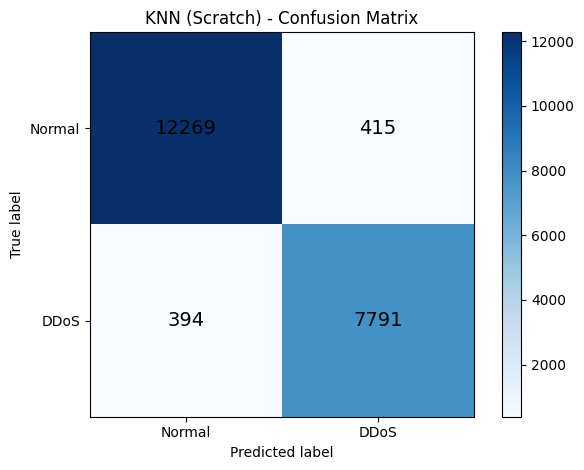

In [8]:
cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Normal','DDoS'])
ax.set_yticklabels(['Normal','DDoS'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('KNN (Scratch) - Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', color='black', fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.show()

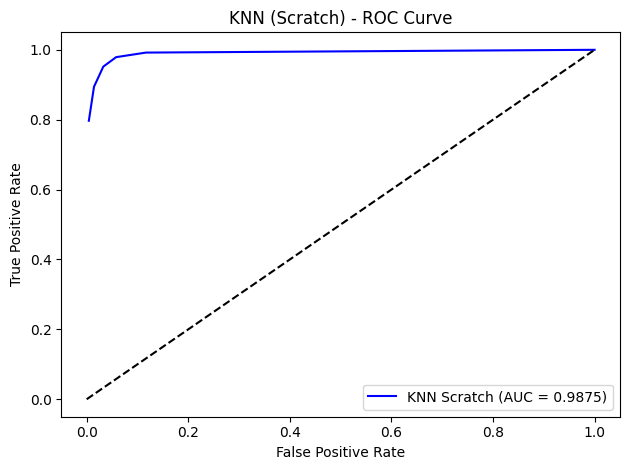

In [9]:
plt.figure()
plt.plot(fprs, tprs, label=f'KNN Scratch (AUC = {auc:.4f})', color='blue')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN (Scratch) - ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()